# Учимся работе с данными - от загрузки до моделирования

## Часть 1 EDA

### 1.1 Скачайте датасет по ссылке: https://www.kaggle.com/uciml/breast-cancer-wisconsin-data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

try:
    df = pd.read_csv('data.csv')
    print("Датасет успешно загружен.")
except FileNotFoundError:
    print("Ошибка: Файл data.csv не найден в текущей директории.")

print("\n--- Первые 5 строк ---")
display(df.head())

print("\n--- Информация о столбцах и типах данных ---")
df.info()

print("\n--- Проверка пропусков ---")
print(df.isnull().sum().sum(), "пропусков в данных")

Датасет успешно загружен.

--- Первые 5 строк ---


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



--- Информация о столбцах и типах данных ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-n

In [2]:
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

print("Размер датасета после очистки:", df.shape)
display(df.head())

print("\n--- Проверка пропусков ---")
print(df.isnull().sum().sum(), "пропусков в данных")

Размер датасета после очистки: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



--- Проверка пропусков ---
0 пропусков в данных


### 1.2 Посмотрите на базовые статистики датасета: средние, медианы и т.д.

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744



--- Количество диагнозов ---
diagnosis
B    357
M    212
Name: count, dtype: int64


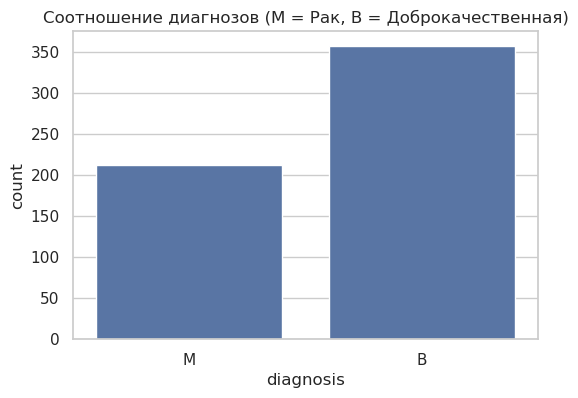

In [3]:
display(df.describe().T)

print("\n--- Количество диагнозов ---")
print(df['diagnosis'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=df)
plt.title("Соотношение диагнозов (M = Рак, B = Доброкачественная)")
plt.show()

## 1.3 Постройте гистограммы/распределения признаков, при этом используйте целевую переменную, чтобы сгруппировать и раскрасить гистограммы.

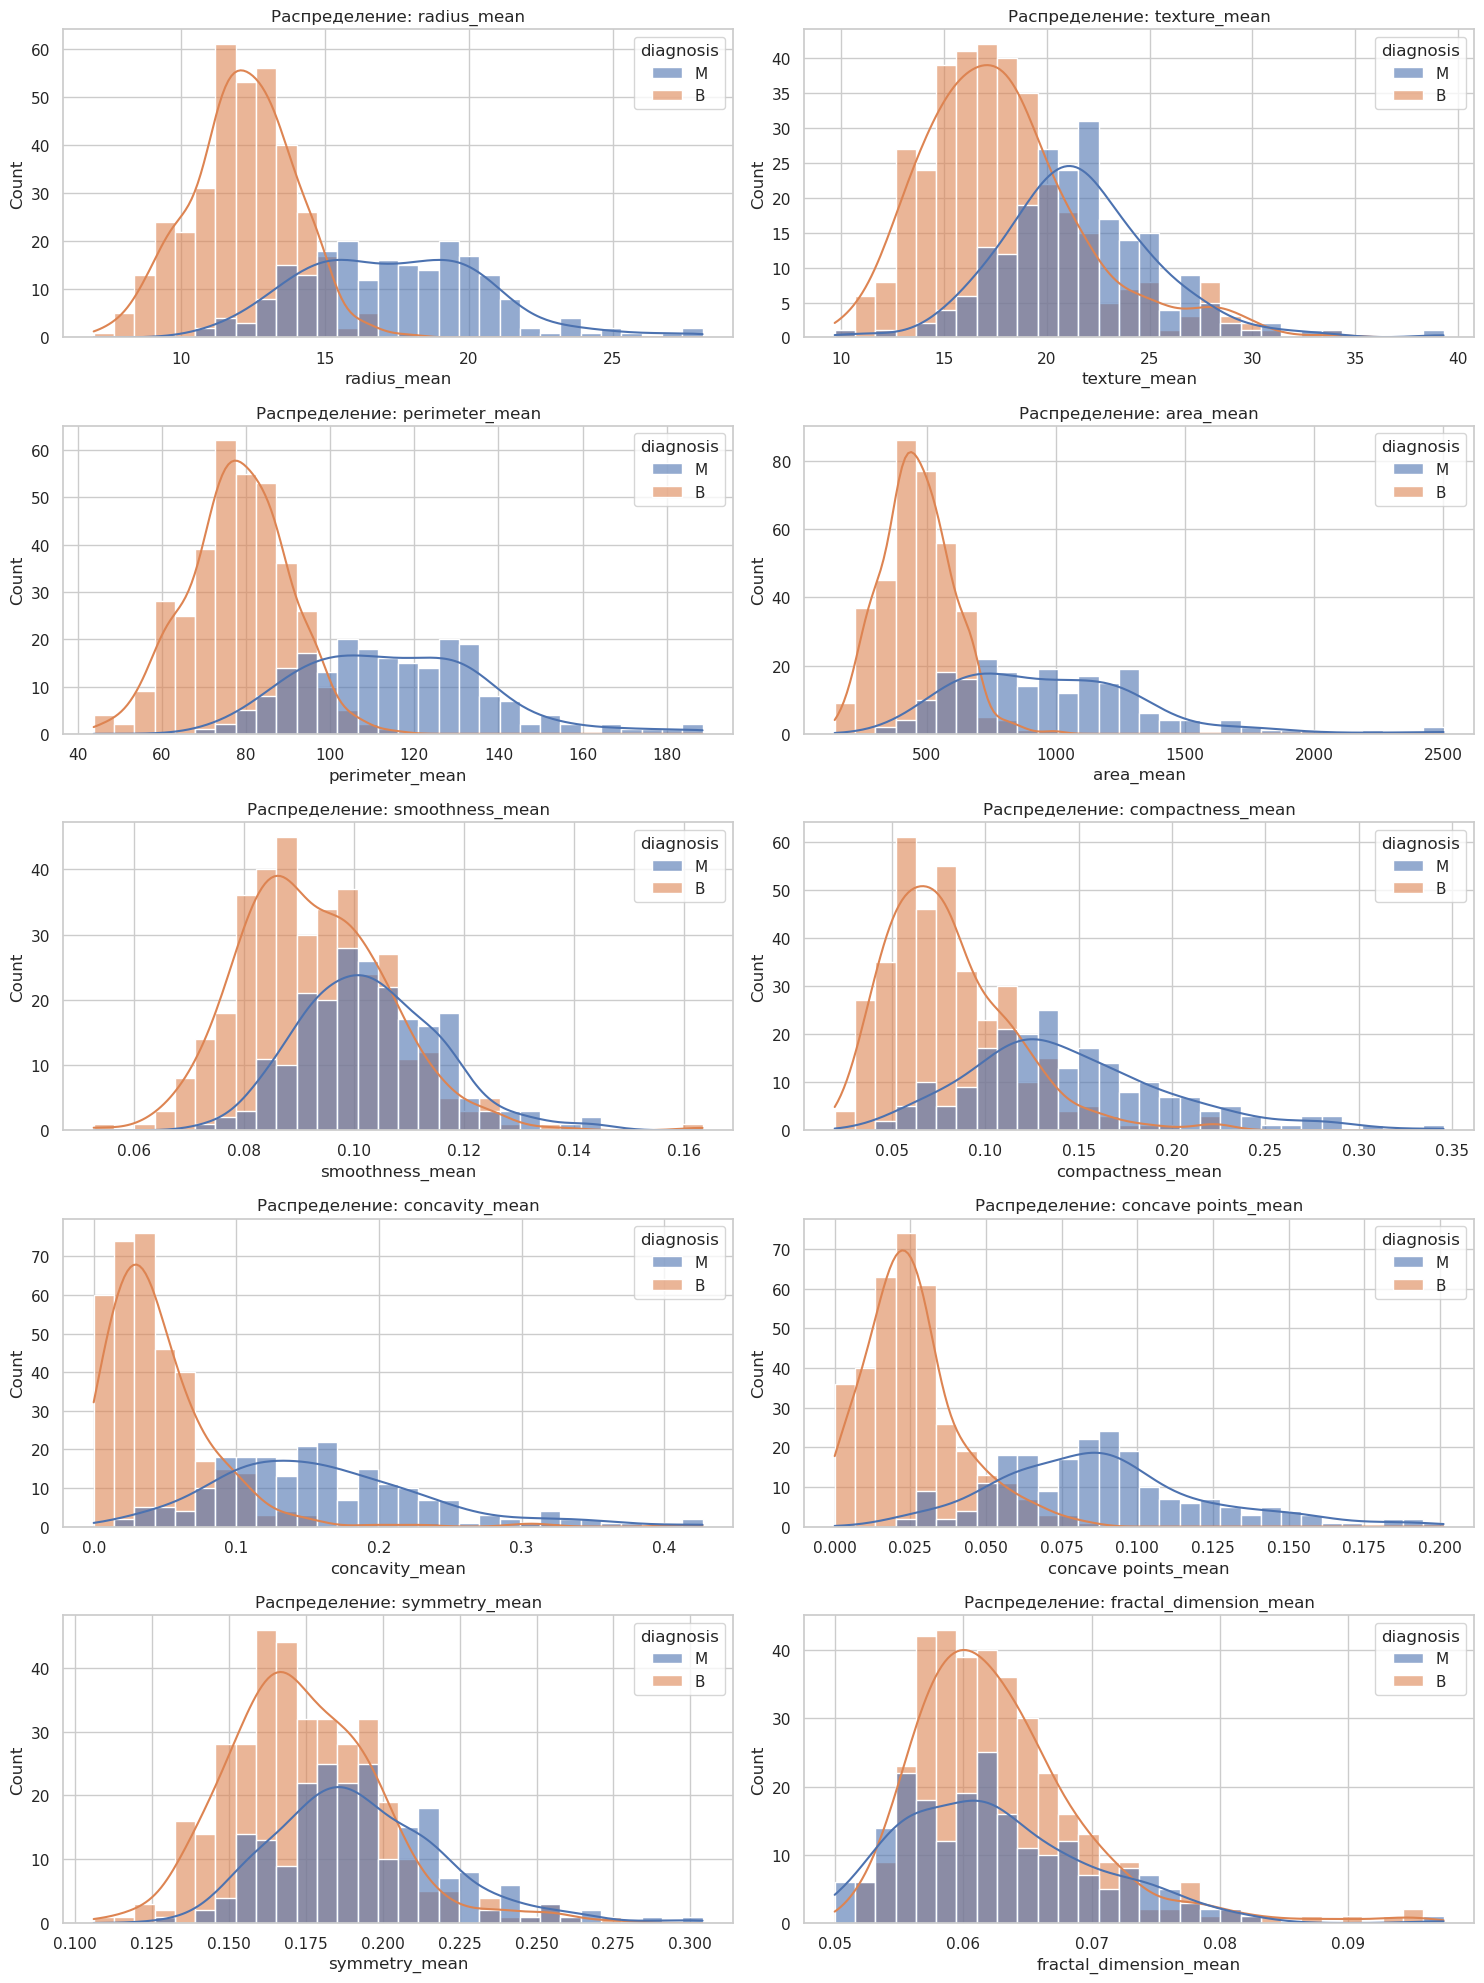

In [4]:
features_mean = [col for col in df.columns if '_mean' in col]

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(features_mean):
    sns.histplot(data=df, x=col, hue='diagnosis', kde=True, ax=axes[i], bins=30, alpha=0.6)
    axes[i].set_title(f"Распределение: {col}")

plt.tight_layout()
plt.show()

## 1.4 Постройте heatmap для матрицы корреляций, есть ли признаки, которые сильно скоррелированы? Какие это признаки?

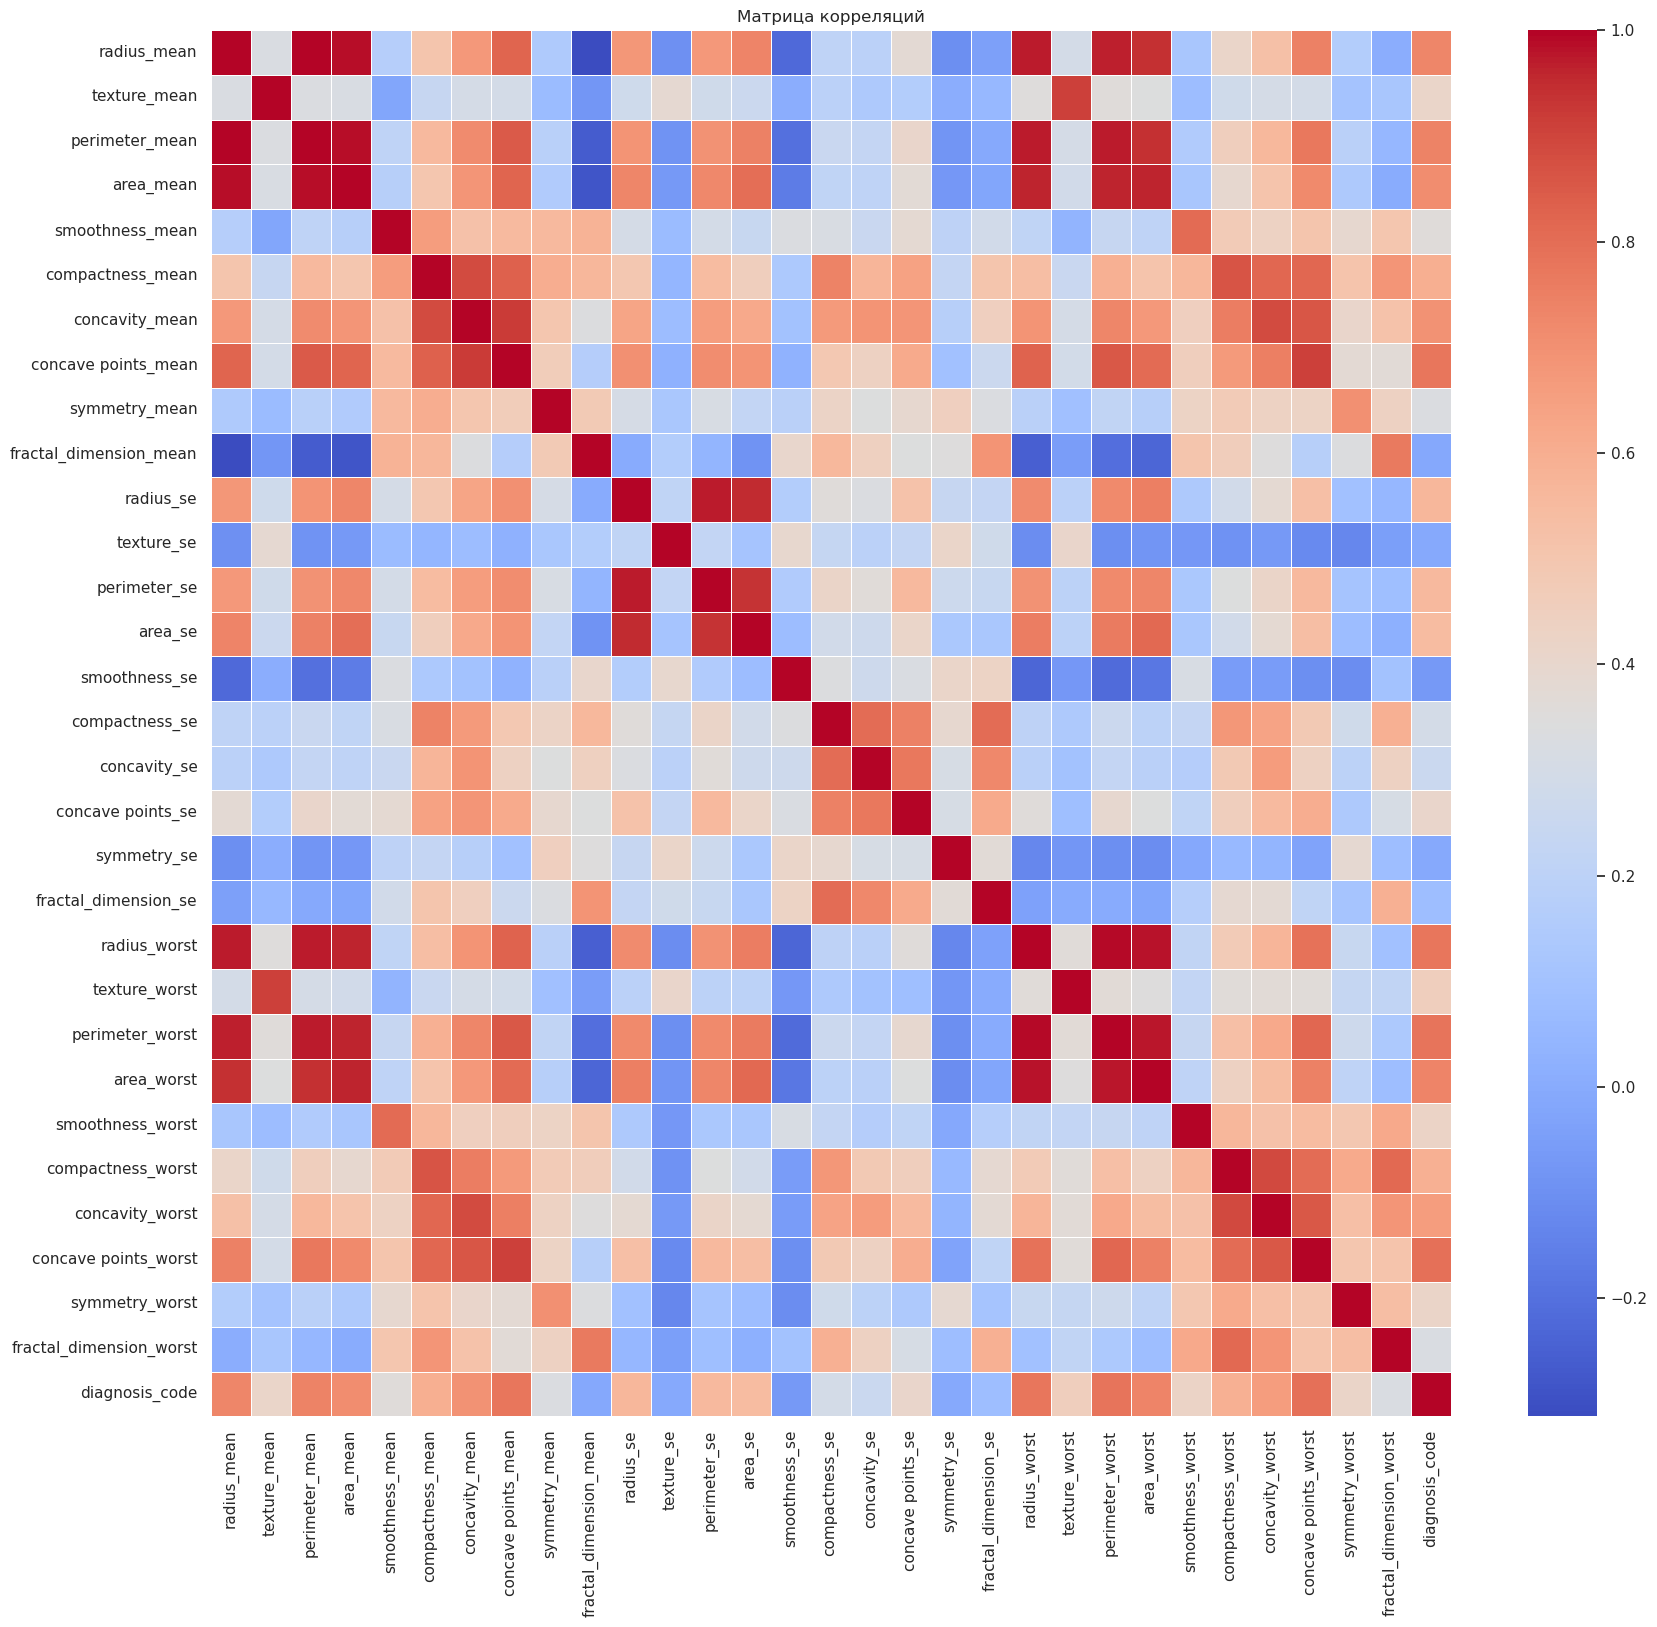

Топ-10 признаков, влияющих на диагноз (корреляция с diagnosis_code):
diagnosis_code          1.000000
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
Name: diagnosis_code, dtype: float64


In [5]:
df['diagnosis_code'] = df['diagnosis'].map({'M': 1, 'B': 0})

corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(20, 18))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Матрица корреляций")
plt.show()

print("Топ-10 признаков, влияющих на диагноз (корреляция с diagnosis_code):")
print(corr_matrix['diagnosis_code'].sort_values(ascending=False).head(11))

На тепловой карте видно, что между собой сильно коррелируют периметр, радиус и площадь. Но это понятно и до анализа и не требует объяснения почему.

## 1.5 Постройте для сильно скоррелированных признаков попарные scatterplot-ы, действительно ли наблюдается линейная зависимость?

Топ-5 самых скоррелированных пар признаков:


radius_mean     perimeter_mean     0.997855
radius_worst    perimeter_worst    0.993708
radius_mean     area_mean          0.987357
perimeter_mean  area_mean          0.986507
radius_worst    area_worst         0.984015
dtype: float64

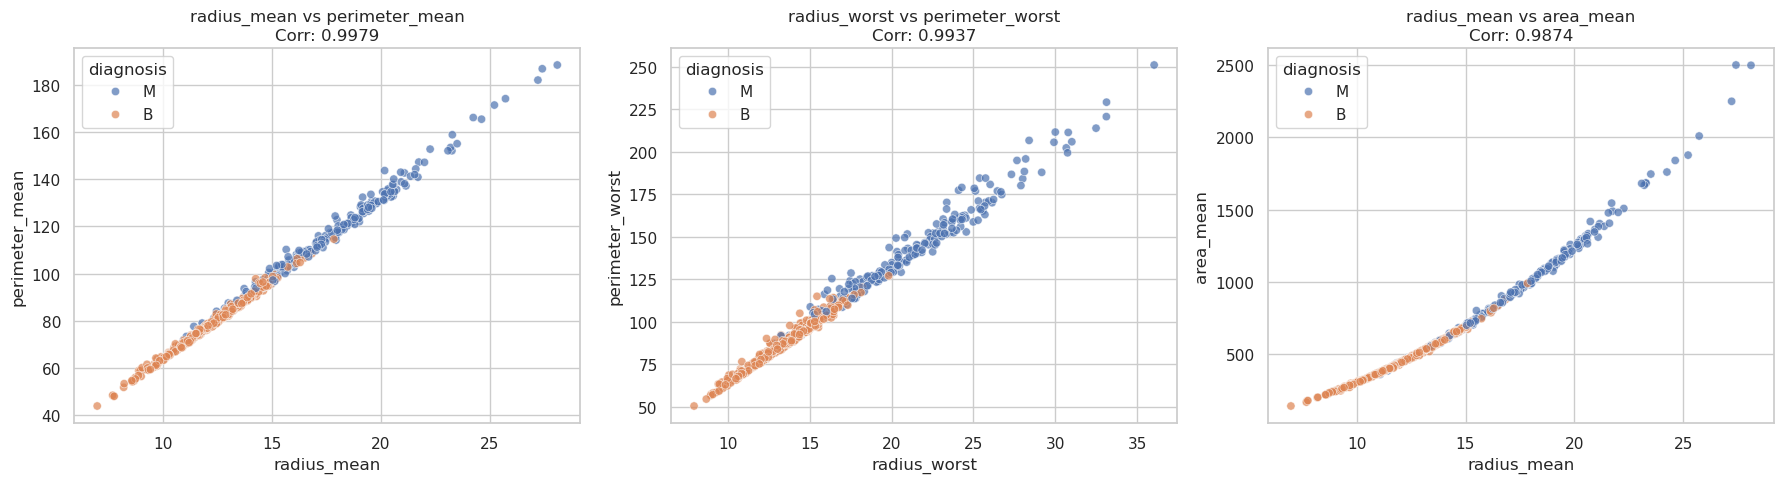

In [6]:
corr_matrix_features = df.drop(columns=['diagnosis', 'diagnosis_code'], errors='ignore').corr().abs()

upper_tri = corr_matrix_features.where(np.triu(np.ones(corr_matrix_features.shape), k=1).astype(bool))

sorted_pairs = upper_tri.stack().sort_values(ascending=False)

print("Топ-5 самых скоррелированных пар признаков:")
display(sorted_pairs.head(5))

top_3_pairs = sorted_pairs.head(3).index.tolist()

plt.figure(figsize=(18, 5))

for i, (feature_1, feature_2) in enumerate(top_3_pairs):
    plt.subplot(1, 3, i+1)
    sns.scatterplot(data=df, x=feature_1, y=feature_2, hue='diagnosis', alpha=0.7)
    plt.title(f"{feature_1} vs {feature_2}\nCorr: {sorted_pairs.iloc[i]:.4f}")

plt.tight_layout()
plt.show()

Видно, что периметр связан с радиусом линейной зависимостью. А площаль с радиусом квадратичной. Тут опять же ничего удивительного 🤷‍♂️

## 1.6 Используя boxplots и группировку по целевой переменной, попробуйте предположить, по каким признакам наиболее удобно было бы отделить злокачественные новообразования от доброкачественных.

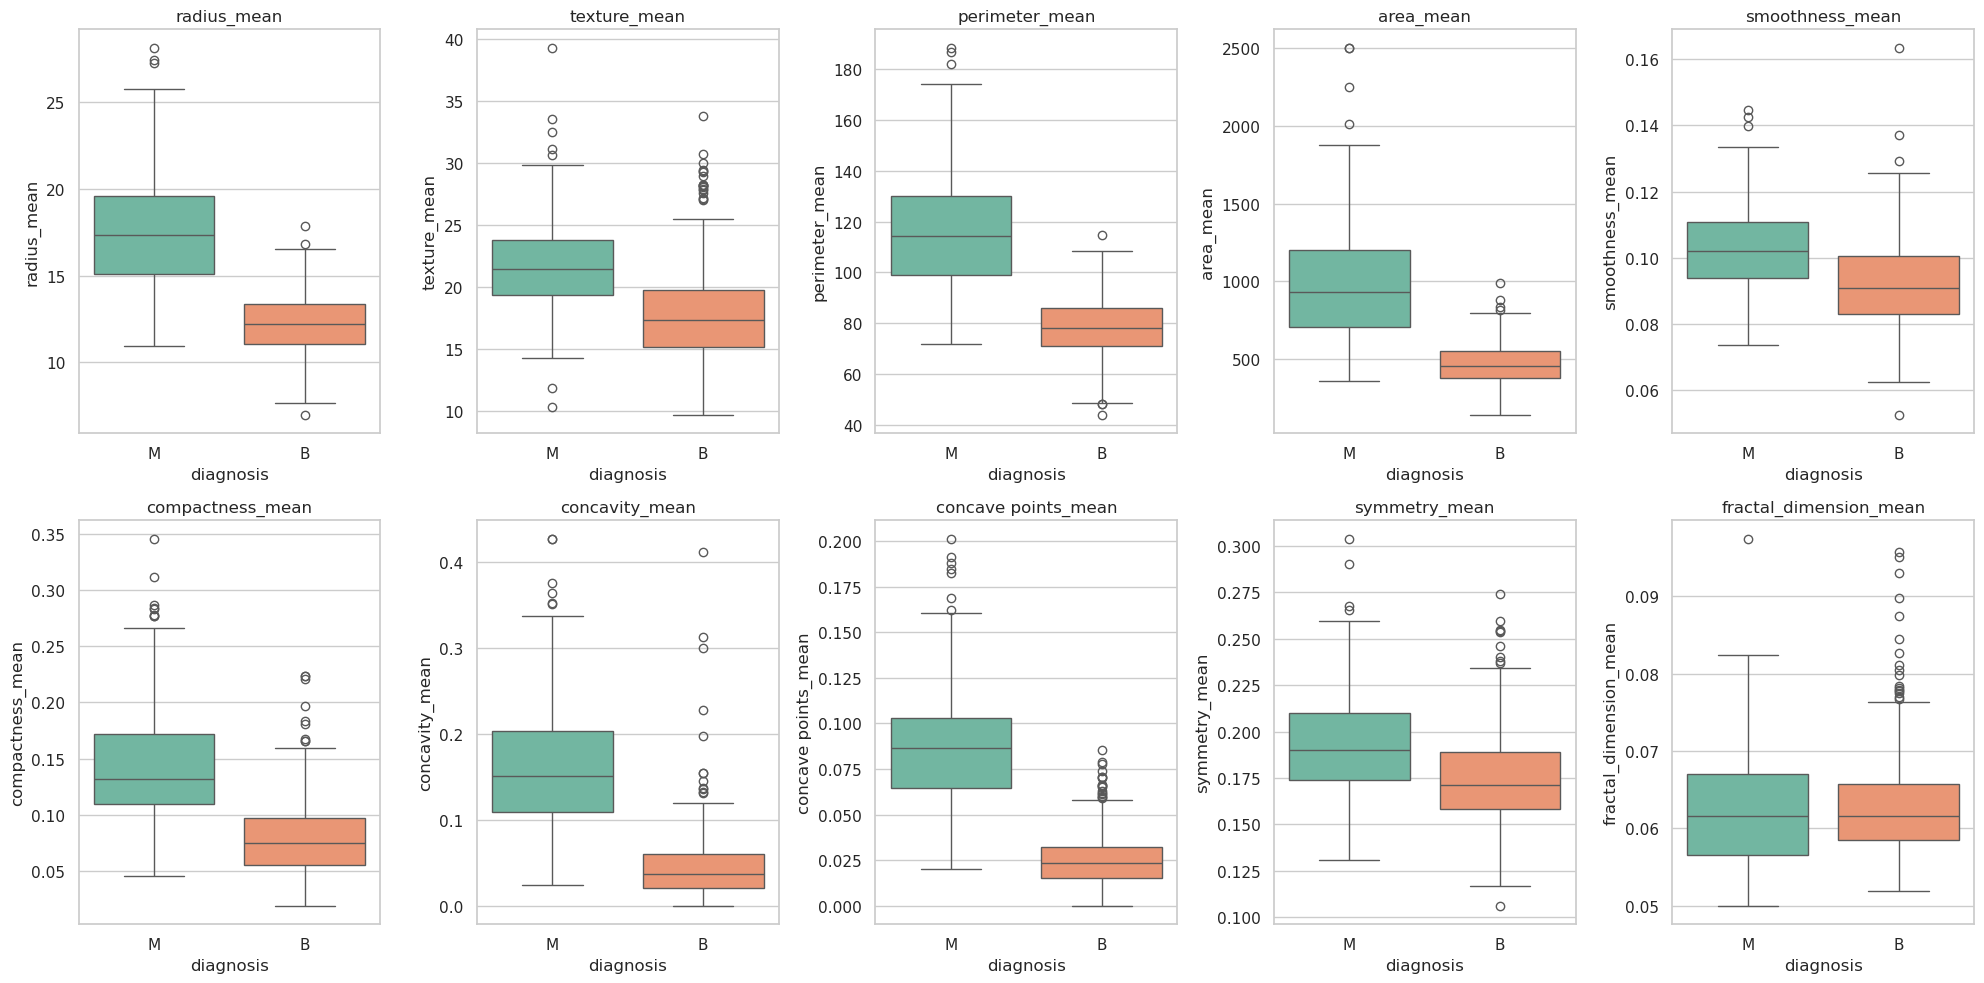

In [7]:
features_mean = [col for col in df.columns if '_mean' in col]

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(features_mean):
    sns.boxplot(x='diagnosis', y=col, hue='diagnosis', data=df, ax=axes[i], palette='Set2', legend=False)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

Судя по боксам лучшие признаки это: сoncave points, area/radius, concavity

## Часть 2. Моделирование при помощи kNN

### 2.1 Разбейте данные на train-test, отложив 30% выборки для тестирования.

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['diagnosis', 'diagnosis_code'], errors='ignore')

y = df['diagnosis'].map({'M': 1, 'B': 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Размер обучающей выборки (X_train):", X_train.shape)
print("Размер тестовой выборки (X_test):", X_test.shape)

print("\nБаланс классов в тесте (проверка stratify):")
print(y_test.value_counts(normalize=True))

Размер обучающей выборки (X_train): (398, 30)
Размер тестовой выборки (X_test): (171, 30)

Баланс классов в тесте (проверка stratify):
diagnosis
0    0.625731
1    0.374269
Name: proportion, dtype: float64


### 2.2 Приведите все непрерывные переменные к одному масштабу при помощи стандартизации. Кратко поясните, почему стандартизация здесь нужна.

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Пример данных после стандартизации (первые 5 строк):")
display(X_train_scaled.iloc[:5, :5])

print("\nСреднее значение столбцов (должно быть очень близко к 0):")
print(X_train_scaled.mean().head())

print("\nСтандартное отклонение (должно быть равно 1):")
print(X_train_scaled.std().head())

Пример данных после стандартизации (первые 5 строк):


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean
0,1.705820,1.049745,2.121295,1.669337,2.276458
1,0.536388,-0.909945,0.569095,0.390316,-0.065868
2,-0.131456,-0.993336,-0.148848,-0.211543,-0.916169
3,0.928077,1.418055,0.925405,0.828546,0.329734
4,0.144699,-0.972488,0.158315,-0.009697,1.205760



Среднее значение столбцов (должно быть очень близко к 0):
radius_mean        4.463208e-17
texture_mean      -4.407418e-16
perimeter_mean     7.933352e-16
area_mean          5.355850e-17
smoothness_mean   -1.640229e-16
dtype: float64

Стандартное отклонение (должно быть равно 1):
radius_mean        1.001259
texture_mean       1.001259
perimeter_mean     1.001259
area_mean          1.001259
smoothness_mean    1.001259
dtype: float64


Алгоритм kNN использует метрику расстояния для поиска соседей. В датасете признаки имеют разный масштаб.
Без стандартизации признаки с большими значениями будут вносить большой вклад в расчет расстояния.

### 2.3 Постройте модель kNN «из коробки» без настройки параметров. Оцените метрики качества бинарной классификации (accuracy, precision, recall, f1_score), постройте ROC-кривую и посчитайте площадь под ней.

Метрики качества (kNN 'из коробки'):
Accuracy (Точность):   0.9649
Precision (Точность+): 1.0000
Recall (Полнота):      0.9062
F1 Score:              0.9508
ROC-AUC:               0.9882


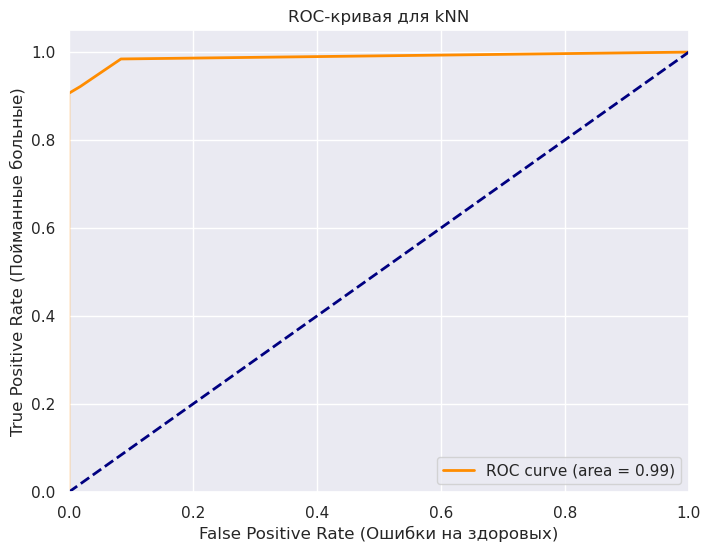

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

y_pred_proba = knn.predict_proba(X_test_scaled)[:, 1]

print("Метрики качества (kNN 'из коробки'):")
print(f"Accuracy (Точность):   {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision (Точность+): {precision_score(y_test, y_pred):.4f}")
print(f"Recall (Полнота):      {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:              {f1_score(y_test, y_pred):.4f}")
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC:               {roc_auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Ошибки на здоровых)')
plt.ylabel('True Positive Rate (Пойманные больные)')
plt.title('ROC-кривая для kNN')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Вот сухая оценка полученных метрик:

*   **Accuracy (0.965):** Модель работает с высокой общей точностью, верно определяя диагноз в 96.5% случаев.
*   **Precision (1.000):** Идеальный результат. Ложных срабатываний нет: если модель предсказывает рак, пациент гарантированно болен.
*   **Recall (0.906):** Модель пропускает около 9.4% реальных больных (ложноотрицательные ответы). Это требует улучшения.
*   **F1 Score (0.951):** Высокое значение показывает хороший баланс, но не отменяет проблемы с пропуском части больных.

### 2.4 Теперь проведите настройку параметра числа соседей на кросс-валидации. Снова оцените результаты, стало ли лучше? :)

Лучшее число соседей: 10
Лучший ROC-AUC на кросс-валидации: 0.9893

--- Метрики после настройки ---
Accuracy:   0.9532
Precision:  0.9828
Recall:     0.8906
F1 Score:   0.9344
ROC-AUC:    0.9885


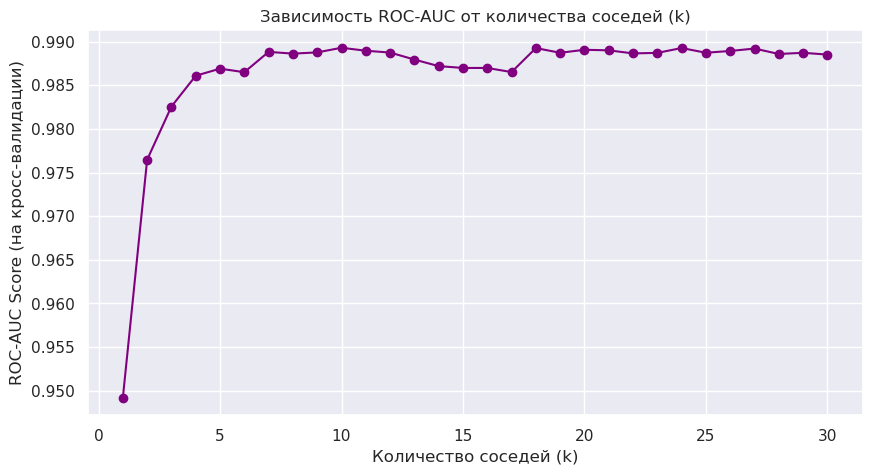

In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': np.arange(1, 31)}

knn_grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='roc_auc', n_jobs=-1)

knn_grid.fit(X_train_scaled, y_train)

print(f"Лучшее число соседей: {knn_grid.best_params_['n_neighbors']}")
print(f"Лучший ROC-AUC на кросс-валидации: {knn_grid.best_score_:.4f}")

best_knn = knn_grid.best_estimator_

y_pred_optimized = best_knn.predict(X_test_scaled)
y_pred_proba_optimized = best_knn.predict_proba(X_test_scaled)[:, 1]

print("\n--- Метрики после настройки ---")
print(f"Accuracy:   {accuracy_score(y_test, y_pred_optimized):.4f}")
print(f"Precision:  {precision_score(y_test, y_pred_optimized):.4f}")
print(f"Recall:     {recall_score(y_test, y_pred_optimized):.4f}")
print(f"F1 Score:   {f1_score(y_test, y_pred_optimized):.4f}")
print(f"ROC-AUC:    {roc_auc_score(y_test, y_pred_proba_optimized):.4f}")

results = knn_grid.cv_results_['mean_test_score']

plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, 31), results, marker='o', linestyle='-', color='purple')
plt.title('Зависимость ROC-AUC от количества соседей (k)')
plt.xlabel('Количество соседей (k)')
plt.ylabel('ROC-AUC Score (на кросс-валидации)')
plt.grid(True)
plt.show()

Результаты на тестовой выборке не улучшились.
Основные метрики (Accuracy и Recall) незначительно снизились, вырос только ROC-AUC (с 0.9882 до 0.9885). Это означает, что базовая модель (k = 5) уже была близка к оптимуму для этих данных, а увеличение числа соседей до 10 сделало модель более устойчивой, но не более точной на данном тестовом наборе.